In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVR, LinearSVR
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, BayesianRidge

from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score, PredictionErrorDisplay

from tqdm.notebook import tqdm
from time import time
import warnings

warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 1000)
# plt.style.use("ggplot")
sns.set_style("whitegrid")

PALETTE = ['#3A86FF', '#F94144', '#FFA10A', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

COLOR = "\033[32m"
RESET = "\033[0m"

## 1.__LOAD DATA

In [2]:
train  = pd.read_csv('/kaggle/input/playground-series-s6e1/train.csv').drop(['id'], axis=1)
submit = pd.read_csv('/kaggle/input/playground-series-s6e1/sample_submission.csv')
TARGET = train.columns[-1]
y      = train[TARGET].values.ravel()
SEED   = 42

print(f"✓ Train data load")

✓ Train data load


In [3]:
## -- Append predicted columns as extra features --
## -- os.walk: Deep search with subfolders --
def dataloader(filepath, train_prefix, test_prefix):    
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()
    
    print('Loading .npy files: ', end='')
    for (root, dirs, files) in os.walk(filepath):
        for i, file in enumerate(sorted(files), 1):
            if i%5 == 0: print(f'{i}%.. ', end='')
            if file.endswith('.npy') and train_prefix in file:
                train_path = np.load(os.path.join(root, file))
                train_df = pd.concat([train_df, pd.Series(train_path, name=file[4:-4])], axis=1)
            elif file.endswith('.npy') and test_prefix in file:
                test_path = np.load(os.path.join(root, file))
                test_df = pd.concat([test_df, pd.Series(test_path, name=file[5:-4])], axis=1)
    print()

    print('Loading .parquet files: ', end='')
    for (root, dirs, files) in os.walk(filepath):
        for i, file in enumerate(sorted(files), 1):
            if i%5 == 0: print(f"{i}%.. ", end="")
            if file.endswith('.parquet') and train_prefix in file:
                train_path = os.path.join(root, file)
                train_df = pd.concat([train_df, pd.read_parquet(train_path)], axis=1)
            elif file.endswith('.parquet') and test_prefix in file:
                test_path = os.path.join(root, file)
                test_df = pd.concat([test_df, pd.read_parquet(test_path)], axis=1)
    print()
    print(f"Total oof  models: {len(train_df.columns)} || Shape: {train_df.shape}")
    print(f"Total pred models: {len(test_df.columns)} || Shape: {test_df.shape}")
    print()

    return train_df, test_df

In [4]:
def rename_duplicate_cols(df: pd.DataFrame) -> pd.DataFrame:
    original_cols = list(df.columns)
    new_cols = []
    # Track how many times we've seen each original name
    seen = {}

    for col in tqdm(original_cols, desc="Fixing columns"):
        if col not in seen:
            # First occurrence: keep name unchanged
            seen[col] = 1
            new_cols.append(col)
        else:
            # Duplicate: append suffix _k where k starts at 0
            suffix = seen[col] - 1 # 0 for first duplicate, 1 for second,
            new_name = f"{col}_{suffix}"
            new_cols.append(new_name)
            seen[col] += 1

    # Apply new column names
    df_renamed = df.copy()
    df_renamed.columns = new_cols
    print(f"{COLOR}Columns fixed!!!{RESET}")

    return df_renamed


In [5]:
PATHS = [
    '/kaggle/input/',
]

## -- Load dataframes --
oofs = []
preds  = []

## -- Load train/test datasets --
for p in PATHS:
    tr, ts = dataloader(p, 'oof', 'test')
    oofs.append(tr)
    preds.append(ts)

## -- Concat datasets --
oof_df = pd.concat(oofs, axis=1)
pred_df  = pd.concat(preds, axis=1)

print('OOF/TEST shape:', oof_df.shape, pred_df.shape)

# ## -- Drop models if necessary --
# for c in oof_df.columns:
#     if 'L2' in c or 'L3' in c: #
#         oof_df.drop([c], axis=1, inplace=True)
#         pred_df.drop([c], axis=1, inplace=True)
#     elif c == TARGET:
#         oof_df.drop([c], axis=1, inplace=True)
        
print('-'*50)

## -- Check for missingness --
print(f'Train Null values: {oof_df.isna().sum().sum()}')
print(f'Test  Null values: {pred_df.isna().sum().sum()}')

print('-'*50)

## -- Apply column rename function --
oof_df = rename_duplicate_cols(oof_df)
pred_df = rename_duplicate_cols(pred_df)

print()

display(oof_df.head(3))
print()
display(pred_df.head(3))

Loading .npy files: 5%.. 5%.. 5%.. 10%.. 5%.. 10%.. 15%.. 20%.. 5%.. 10%.. 5%.. 
Loading .parquet files: 5%.. 5%.. 5%.. 10%.. 5%.. 10%.. 15%.. 20%.. 5%.. 10%.. 5%.. 
Total oof  models: 63 || Shape: (630000, 63)
Total pred models: 63 || Shape: (270000, 63)

OOF/TEST shape: (630000, 63) (270000, 63)
--------------------------------------------------
Train Null values: 0
Test  Null values: 0
--------------------------------------------------


Fixing columns:   0%|          | 0/63 [00:00<?, ?it/s]

Columns fixed!!!


Fixing columns:   0%|          | 0/63 [00:00<?, ?it/s]

Columns fixed!!!



,py_catb_62892,py_lgb_61185,py_mlpPLR_68655,py_mlpRTDL_66901,py_resRTDL_65146,py_tabM_60593,py_xgb_60595,XGB_gbdt_60118,XGB_loss_60249,XGB_grad_60263,XGBxtend_gbdt_61003,XGBxtend_loss_61085,XGBxtend_gbdt_61003_0,XGBxtend_loss_61085_0,XGBgbdt_59989,XGBloss_60124,XGBgrad_60152,bartz_base_66306,bartz_tabM_pseudo_65653,xgb_over_lr,xgb_over_ridgeCV,xgb_over_mlp,xgb_over_lr_0,xgb_over_ridgeCV_0,xgb_over_mlp_0,hist__69968,hist_cme__69758,hist_TE__6898,hist_cme_TE_69097,hist__6964,hist_cme__69907,hist_TE__69375,hist_cme_TE_68866,ridge_stack76781,sk_hc76798,xgb_tabM0_pseudo_59841,xgb_tabM1_pseudo_59851,xgb_tabM2_pseudo_59842,xgb_tabM3_pseudo_59842,xgb_tabM_pseudo_60575,py_tabM3_meta+fe60124,py_tabM2_meta+fe60589,py_tabM_meta+fe6106,xgb_basescore_602,xgb_basescore_60549,xgb_basescore_6067,xgb_gbdt_ext_60445,xgb_loss_ext_005_60676,xgb_AG_basescore5_60594,xgb_AG_basescore5_60817,LGB_bag_540_8_61275,LGB_bag_540_8_cme_61794,LGB_goss_540_8_61089,LGB_goss_540_8_cme_61386,LGB_bag_480_-1_61043,LGB_bag_480_-1_cme_61908,LGB_goss_480_-1_60953,LGB_goss_480_-1_cme_61656,LGB_bag_540_-1_61059,LGB_bag_540_-1_cme_61349,LGB_goss_540_-1_60957,LGB_goss_540_-1_cme_6124,lgb_goss_ext_005_61092
0,86.688492,86.140564,85.738118,85.902185,87.139495,86.612518,86.144653,85.782745,85.731857,85.992737,86.586670,86.881119,86.586670,86.881119,85.708923,85.808243,85.915421,86.130020,85.914291,87.516899,88.327248,86.565460,87.287926,87.025757,86.068924,85.353533,85.687152,85.409210,85.374487,84.384845,85.141444,85.290123,85.784180,85.034216,85.093428,86.187370,86.370224,86.219353,87.097427,86.268631,85.920105,86.170883,85.917885,86.154221,85.515030,85.649948,86.771828,87.210014,86.513184,86.922592,85.318904,85.387741,85.742981,84.997785,85.680118,85.773735,85.706107,85.654820,85.651155,86.001912,85.575590,85.819090,87.217672
1,62.633961,61.034485,62.166407,61.022569,60.568737,61.261623,61.474064,60.526791,61.457813,61.206097,61.844688,62.011227,61.844688,62.011227,61.312813,61.000328,61.397327,62.045822,61.573631,62.838547,63.109093,62.679665,63.699028,64.167763,63.423134,64.307580,64.505596,62.963127,63.299097,63.259405,63.964815,63.577783,63.558337,63.930631,63.771228,61.267548,61.711746,61.394009,61.783325,61.147091,60.960331,61.302273,61.855743,61.211216,61.538975,61.225441,62.271206,62.502407,61.238247,61.462227,61.292052,62.674258,61.815940,62.707770,61.340938,61.198899,60.826019,61.027153,60.666148,62.591098,61.052287,62.498479,62.491562
2,75.477058,74.895561,74.309942,73.567834,72.474952,73.059113,75.284302,74.903198,74.977432,74.916412,73.799271,73.861023,73.799271,73.861023,74.598541,74.384422,74.637077,74.179680,73.660393,74.393341,74.723068,75.265228,74.261093,74.252678,72.927773,75.526277,75.458655,75.434530,75.263758,75.578656,75.774778,74.165394,75.287001,75.928967,75.931758,74.603096,74.824989,74.866760,74.990540,73.924393,73.960136,73.615585,74.100609,73.914948,74.107468,74.164413,74.198845,73.925819,75.255173,75.465096,74.226975,74.905604,74.767358,74.023411,74.464471,74.504888,74.688106,74.405696,74.360232,74.059751,74.425620,74.131461,74.530084


,py_catb_62892,py_lgb_61185,py_mlpPLR_68655,py_mlpRTDL_66901,py_resRTDL_65146,py_tabM_60593,py_xgb_60595,XGB_gbdt_60118,XGB_loss_60249,XGB_grad_60263,XGBxtend_gbdt_61003,XGBxtend_loss_61085,XGBxtend_gbdt_61003_0,XGBxtend_loss_61085_0,XGBgbdt_59989,XGBloss_60124,XGBgrad_60152,bartz_base_66306,bartz_tabM_pseudo_65653,xgb_over_lr,xgb_over_ridgeCV,xgb_over_mlp,xgb_over_lr_0,xgb_over_ridgeCV_0,xgb_over_mlp_0,hist__69968,hist_cme__69758,hist_TE__6898,hist_cme_TE_69097,hist__6964,hist_cme__69907,hist_TE__69375,hist_cme_TE_68866,ridge_stack76781,sk_hc76798,xgb_tabM0_pseudo_59841,xgb_tabM1_pseudo_59851,xgb_tabM2_pseudo_59842,xgb_tabM3_pseudo_59842,xgb_tabM_pseudo_60575,py_tabM3_meta+fe60124,py_tabM2_meta+fe60589,py_tabM_meta+fe6106,xgb_basescore_602,xgb_basescore_60549,xgb_basescore_6067,xgb_gbdt_ext_60445,xgb_loss_ext_005_60676,xgb_AG_basescore5_60594,xgb_AG_basescore5_60817,LGB_bag_540_8_61275,LGB_bag_540_8_cme_61794,LGB_goss_540_8_61089,LGB_goss_540_8_cme_61386,LGB_bag_480_-1_61043,LGB_bag_480_-1_cme_61908,LGB_goss_480_-1_60953,LGB_goss_480_-1_cme_61656,LGB_bag_540_-1_61059,LGB_bag_540_-1_cme_61349,LGB_goss_540_-1_60957,LGB_goss_540_-1_cme_6124,lgb_goss_ext_005_61092
0,69.937656,68.801832,69.578282,70.544626,69.844086,70.16837,68.356943,68.806736,69.047075,68.926661,69.063478,69.184321,69.063478,69.184321,68.885216,69.175027,68.978607,69.479706,69.557053,70.513012,70.597206,70.711028,70.189158,70.170502,69.670619,70.473159,70.286991,70.855875,71.198036,70.351699,70.308357,70.860897,71.218049,71.906423,71.864230,68.906935,68.510226,68.871183,68.382638,68.742071,70.051081,69.986753,69.887014,68.628630,68.717550,68.984600,68.819203,69.015012,68.579308,68.672778,69.085864,69.226077,68.976145,68.933155,68.902509,68.820401,68.904376,68.744666,68.983265,68.972823,69.055517,69.149427,69.044581
1,69.269369,68.820347,66.634049,67.672073,66.006580,66.92374,68.975389,68.434294,68.426260,68.380260,67.413956,67.474291,67.413956,67.474291,68.332038,68.307899,68.355513,67.693649,68.646309,70.852183,70.855190,70.723640,69.450539,69.281650,68.584525,69.394816,69.790828,68.684939,69.029887,69.881703,69.535291,68.489706,68.821750,70.525372,70.498294,67.903807,68.547585,67.919798,68.441369,66.791371,65.911273,66.586623,66.182148,68.538184,67.810481,68.528937,67.655030,67.731277,69.844801,69.293248,68.505683,68.520475,68.597972,68.482443,68.695055,68.630278,68.768327,68.435194,68.608486,68.886083,68.795293,68.694330,68.317784
2,88.729725,89.624125,90.277119,90.985393,90.548849,90.62045,90.009252,90.245839,90.303782,90.116723,90.451480,90.457949,90.451480,90.457949,90.171266,90.419130,90.066766,88.184113,89.441544,87.900454,88.064122,88.024510,88.993005,89.002260,89.184582,88.894744,88.711039,88.880809,88.855335,88.833979,88.819031,89.082933,88.829361,87.477449,87.554938,91.265516,90.848653,91.282242,90.670236,90.634073,90.260964,90.660124,90.886374,90.764555,90.494648,90.997976,90.457200,90.401023,90.243106,90.934801,90.124104,89.648565,89.940830,89.636872,90.276528,89.542762,90.288202,89.691004,90.297098,89.826149,90.210182,89.924384,89.742585


In [6]:
## -- Confirm feature names consistency --
for i, enum in enumerate([oof_df.columns == pred_df.columns]):
    print(i, enum)

0 [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True]


In [7]:
# for k, v in zip(oof_df.columns, pred_df.columns):
#     print(f"{k:<25} ---| {v}")

In [8]:
print(f"""
-> OOF shape   : {oof_df.shape}
-> PRED shape  : {pred_df.shape}
-> Target (y)  : {y.shape}
    """)


-> OOF shape   : (630000, 63)
-> PRED shape  : (270000, 63)
-> Target (y)  : (630000,)
    


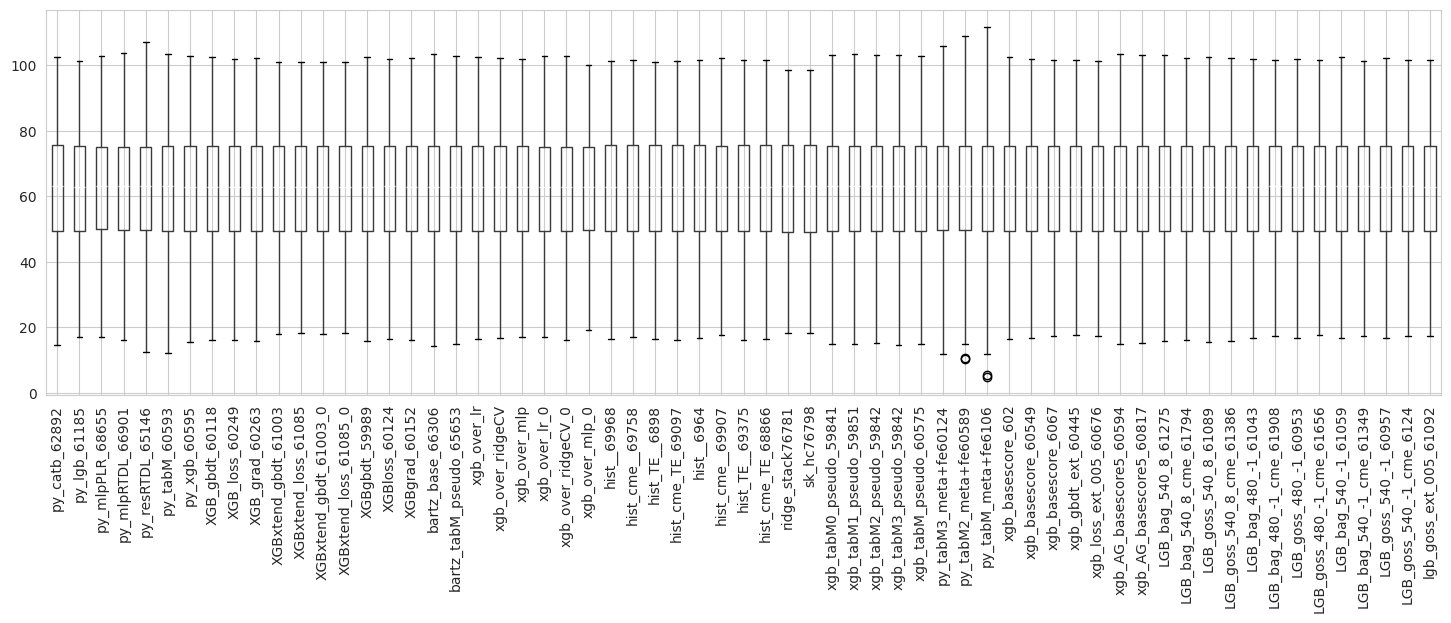

In [9]:
plt.figure(figsize=(18, 5))
oof_df.boxplot(rot=90)
plt.show()

In [10]:
## -- CIR/IR --
# try:
#     from cir_model import CenteredIsotonicRegression
# except:
#     %pip install -qq -U cir-model
#     from cir_model import CenteredIsotonicRegression

# from sklearn.isotonic import IsotonicRegression
# from cir_model import CenteredIsotonicRegression

# CIR_oof_df = pd.DataFrame()
# CIR_pred_df = pd.DataFrame()
# for c in oof_df.columns:
#     CIR = CenteredIsotonicRegression(out_of_bounds='clip').fit(oof_df[c], y)
#     CIR_oof_df[c]  = CIR.transform(oof_df[c])
#     CIR_pred_df[c] = CIR.transform(pred_df[c])

# IR_oof_df = pd.DataFrame()
# IR_pred_df = pd.DataFrame()
# for c in oof_df.columns:
#     IR = IsotonicRegression(out_of_bounds='clip').fit(oof_df[c], y)
#     IR_oof_df[c]  = IR.transform(oof_df[c])
#     IR_pred_df[c] = IR.transform(pred_df[c])

# CIR, IR

# fig, axs = plt.subplots(1, 3, figsize=(20, 5))
# sns.histplot(oof_df.iloc[:, 0], ax=axs[0]).set_title("Original")
# sns.histplot(IR_oof_df.iloc[:, 0], ax=axs[1]).set_title("Isotonic Regression")
# sns.histplot(CIR_oof_df.iloc[:, 0], ax=axs[2]).set_title("Centered Isotonic Regression")
# plt.show()

# pd.concat([oof_df.iloc[:, 0], IR_oof_df.iloc[:, 0], CIR_oof_df.iloc[:, 0]], axis=1).head()

# ENSEMBLE 1: STACKING

In [11]:
# ## -- Stacking with Ridge --
# kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

# alphas = [np.round(x, 3) for x in np.arange(1000, 5001, 1000)]
# cv_scores = []
# print(f"Training Ridge with alphas: {alphas}")
# for i, alpha in enumerate(alphas, 1):
#     print(f"\n{COLOR}[{i}] alpha -> {alpha}{RESET}")
#     RMSE_Scores = []
#     for j, (train_idx, val_idx) in enumerate(kf.split(oof_df), 1):
#         X_tr, X_val = oof_df.iloc[train_idx], oof_df.iloc[val_idx]
#         y_tr, y_val = y[train_idx], y[val_idx]

#         model = Ridge(
#                     # max_iter=5000,
#                     # positive=True,
#                     # solver='lbfgs',
#                     alpha=alpha,
#                     random_state=SEED,
#                 )
        
#         model.fit(X_tr, y_tr)
#         preds = model.predict(X_val)
        
#         score = rmse(y_val, preds)
#         RMSE_Scores.append(score)
#         print(f"Fold {j} alpha: {alpha} | rmse: {score:.6f}")

#     cv_scores.append(np.mean(RMSE_Scores))
#     print(f"{COLOR}Mean Score: {np.mean(RMSE_Scores):.6f} ± {np.std(RMSE_Scores):.6f}{RESET}")
#     print(f"{'='*50}")

# best_alpha = alphas[np.argmin(cv_scores)]
# best_score = np.round(np.min(cv_scores), 6)
# print(f"{COLOR}Best Alpha: {best_alpha} || RMSE: {best_score}{RESET}")
# print(f"{'='*50}")

# ## -- Plot alpha/scores --
# pd.DataFrame.from_dict(dict(zip(alphas, cv_scores)), orient='index')\
#             .plot(figsize=(18, 5), marker='o', markersize=10, linestyle='-.')
# plt.axvline(best_alpha, color='r', linestyle='--', label='best_alpha')
# plt.xticks(alphas)
# plt.legend(loc='center')
# plt.grid(axis='x')
# plt.tight_layout()
# plt.show()

In [12]:
# ## -- Final predictions with best alpha --
# model = RidgeCV(cv=5, scoring='neg_root_mean_squared_error')
# model.fit(oof_df, y)

# model_preds = model.predict(pred_df)
# print(f'Best RidgeCV Score: {-model.best_score_:.5f}')

# submit[TARGET] = model_preds
# display(submit.head())

# print(f"{'='*50}")
# print(f"""
# -> True Mean: {np.mean(y):.6f}
# -> Oof  Mean: {np.mean(oof_df):.6f}
# -> Pred Mean: {np.mean(model_preds):.6f}
#     """)

# sns.histplot(y, label='True', bins=50)
# sns.histplot(model_preds, label='Predictions', bins=50)
# plt.legend(); plt.show()

# n = f"{best_score}".split('.')[1]
# submit.to_csv(f"submit_stack_ridge{n}.csv", index=False)

In [13]:
def train_ridge_meta(oof_df, pred_df, features, y_true, cv_splits=5, n_alphas=10):
    ## -- Stack with RidgeCV meta_model --
    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=SEED)

    oof_ridge_preds = np.zeros(oof_df.shape[0])
    test_ridge_preds = np.zeros(pred_df.shape[0])
    val_scores = []
    for fold, (trn_idx, val_idx) in enumerate(kf.split(oof_df)):
                                                      
        X_trn, y_trn = oof_df[features].iloc[trn_idx], y_true[trn_idx]
        X_val, y_val = oof_df[features].iloc[val_idx], y_true[val_idx]

        ridgeCV = RidgeCV(
            alphas=np.logspace(-2, 4, n_alphas),
            scoring='neg_root_mean_squared_error',
            cv=5,
        )

        model = make_pipeline(StandardScaler(), ridgeCV)
        model.fit(X_trn, y_trn)

        ridge_score = np.round(-model[1].best_score_, 5)
    
        oof_ridge_preds[val_idx] = model.predict(X_val)
        test_ridge_preds += model.predict(pred_df[features])
        
        val_scores.append(root_mean_squared_error(y_val, oof_ridge_preds[val_idx]))
        
        print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.5f} | ", end='')
        print(f"Best Alpha: {model[1].alpha_}")

    test_ridge_preds /= kf.n_splits
    final_rmse = np.round(root_mean_squared_error(y_true, oof_ridge_preds), 5)
    print(f"\n" + "="*35)
    print(f"✅ FINAL ENSEMBLE RMSE: {final_rmse}")
    print("="*35)

    return test_ridge_preds, oof_ridge_preds, final_rmse

In [14]:
%%time

test_ridge, oof_ridge, ridge_score = train_ridge_meta(
    oof_df,
    pred_df,
    oof_df.columns,
    y,
    cv_splits=8,
    n_alphas=20,
)
print()

oof_ridge.shape, test_ridge.shape

Fold 1/8: 8.54128 | Best Alpha: 29.76351441631316
Fold 2/8: 8.59869 | Best Alpha: 29.76351441631316
Fold 3/8: 8.58788 | Best Alpha: 29.76351441631316
Fold 4/8: 8.55296 | Best Alpha: 29.76351441631316
Fold 5/8: 8.57882 | Best Alpha: 29.76351441631316
Fold 6/8: 8.60019 | Best Alpha: 29.76351441631316
Fold 7/8: 8.58206 | Best Alpha: 14.38449888287663
Fold 8/8: 8.58959 | Best Alpha: 29.76351441631316

✅ FINAL ENSEMBLE RMSE: 8.57896

CPU times: user 14min 37s, sys: 1min 1s, total: 15min 39s
Wall time: 6min 34s


((630000,), (270000,))

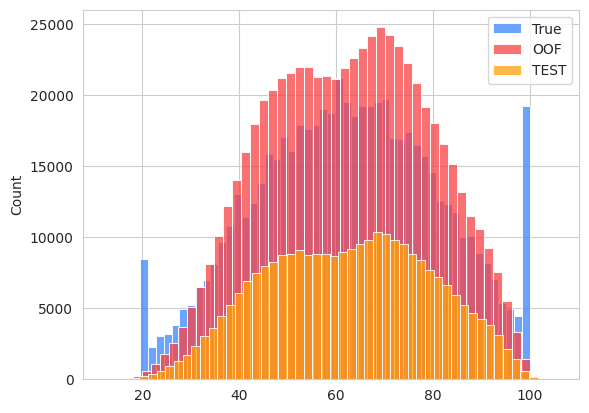

In [15]:
## -- Distribution Plots --
sns.histplot(y, label='True', bins=50)
sns.histplot(oof_ridge, label='OOF', bins=50)
sns.histplot(test_ridge, label='TEST', bins=50)
plt.legend()
plt.show()

In [16]:
# ## -- Create submission file --
# n = f"{ridge_score}".split('.')[1]

# submit[TARGET] = np.clip(test_ridge, min(y), max(y))
# submit.to_csv(f"submit_stack_ridgeCV_{n}.csv", index=False)
# submit.head()

## ~ SELECT BEST MODELS: BETTER PERFORMANCE

[Link to discussion](https://www.kaggle.com/code/adaubas/pss6e01-robust-blend-from-cv-8-5831-to-8-5829?kernelSessionId=291325952)

To detect unnecessary models, we will extract the weights learned by the regression during the blending process and examine their stability. When a model’s weight is positive in some training runs and negative in others, it is a strong indication that the model is not useful for the blend.

In [17]:
kf = KFold(n_splits=8, shuffle=True, random_state=SEED)

coefs, val_scores = pd.DataFrame(), []
oof_ridge_preds = np.zeros(train.shape[0])

for fold, (trn_idx, val_idx) in enumerate(kf.split(train)):
    X_trn, y_trn = oof_df.iloc[trn_idx], train[TARGET].iloc[trn_idx]
    X_val, y_val = oof_df.iloc[val_idx], train[TARGET].iloc[val_idx]
    
    model = make_pipeline(StandardScaler(), LinearRegression())
    model.fit(X_trn, y_trn)

    # Extract regression coefficients
    coefs[f"fold_{fold+1}"] = pd.Series(
        list(model[1].coef_) + [model[1].intercept_], 
        index = list(model[0].get_feature_names_out()) + ["intercept"],
        name = f"fold_{fold + 1}"
    )

    oof_ridge_preds[val_idx] = model.predict(X_val)
    val_scores.append(root_mean_squared_error(y_val, oof_ridge_preds[val_idx]))
    print(f"Fold {fold+1}/{kf.n_splits} : {val_scores[-1:][0]:.6f}")
    
final_rmse = root_mean_squared_error(train[TARGET], oof_ridge_preds)
print(f"\n" + "="*35)
print(f"✅ FINAL ENSEMBLE RMSE: {final_rmse:.6f}")
print("="*35)

coefs.head(10) # View fist 10 models

Fold 1/8 : 8.541351
Fold 2/8 : 8.598711
Fold 3/8 : 8.587993
Fold 4/8 : 8.553122
Fold 5/8 : 8.578894
Fold 6/8 : 8.600308
Fold 7/8 : 8.582045
Fold 8/8 : 8.589802

✅ FINAL ENSEMBLE RMSE: 8.579051


,fold_1,fold_2,fold_3,fold_4,fold_5,fold_6,fold_7,fold_8
py_catb_62892,3.733181,3.659351,3.513674,3.711447,3.894403,3.823650,3.444361,3.768596
py_lgb_61185,-0.349922,-0.431177,0.010260,-0.415270,-0.073403,-0.722867,-0.334755,-0.800093
py_mlpPLR_68655,-0.562254,-0.565873,-0.436030,-0.953269,-0.765693,-0.939018,-0.708119,-0.609560
py_mlpRTDL_66901,0.956894,1.063074,0.928212,0.865084,0.987359,0.878202,1.061676,1.059271
py_resRTDL_65146,-0.009105,0.123991,0.021374,0.390126,0.271492,0.229441,0.216587,0.126968
py_tabM_60593,1.002633,0.975919,0.858267,0.726136,0.824495,0.609336,0.904559,0.665533
py_xgb_60595,-0.012842,0.049577,-0.064006,-0.195554,-0.486442,0.342718,0.277510,-0.348336
XGB_gbdt_60118,0.871490,1.192378,1.243705,1.360451,0.550591,1.410904,0.524821,1.226359
XGB_loss_60249,-1.245567,-1.786661,-1.272099,-0.794744,-1.566248,-1.056837,-0.924645,-1.525714
XGB_grad_60263,-2.039397,-2.804312,-2.507146,-2.162020,-2.755166,-2.889624,-1.805469,-2.086208


The coefficient of the second model, `py_lgb_61185` (the weight assigned) is positive in the 3rd fold, whereas it is negative in the other seven.

This shows that a negative value for this coefficient does not generalize in all cases.

It is therefore tempting to retrain the model while excluding `py_lgb_61185` to see whether the score improves. Let’s try it.

In [18]:
def inspect_models(oof_df, pred_df, target, features, cv_splits=5):

    coefs, val_scores = pd.DataFrame(), []
    oof_final_preds, sub_final_preds = np.zeros(oof_df.shape[0]), np.zeros(pred_df.shape[0])

    kf = KFold(cv_splits, shuffle=True, random_state=SEED)

    for fold, (trn_idx, val_idx) in enumerate(kf.split(train)):
        X_trn, y_trn = oof_df[features].iloc[trn_idx], train[target].iloc[trn_idx]
        X_val, y_val = oof_df[features].iloc[val_idx], train[target].iloc[val_idx]

        model = make_pipeline(StandardScaler(), LinearRegression())
        model.fit(X_trn, y_trn)

        coefs[f"fold_{fold+1}"] = pd.Series(
            list(model[1].coef_) + [model[1].intercept_], 
            index = list(model[0].get_feature_names_out()) + ["intercept"],
            name = f"fold_{fold + 1}"
        )

        oof_final_preds[val_idx] = model.predict(X_val)
        sub_final_preds += model.predict(pred_df[features]) / kf.n_splits
        
        val_scores.append(root_mean_squared_error(y_val, oof_final_preds[val_idx]))
        
        print(f"Fold {fold+1}/{kf.n_splits} : {val_scores[-1:][0]:.5f}")

    final_rmse = root_mean_squared_error(train[target], oof_final_preds)
    print(f"\n" + "="*35)
    print(f"✅ FINAL ENSEMBLE RMSE: {final_rmse:.5f}")
    print("="*35)

    fig, ax = plt.subplots(1, 1, figsize = (18, int(coefs.shape[0]) // 3))
    ax = [ax]

    coefs_ = coefs.loc[[i for i in list(coefs.index) if i not in ["intercept"]]]
    ax[0].boxplot(coefs_.T, vert = False, tick_labels = coefs_.index)
    ax[0].set_title("LR Coefficients (without intercept)")

    for i in range(1):
        ax[i].axvline(x=0, color='r', label='dropline', linewidth=2)
        ax[i].xaxis.set_ticks_position("top")
        ax[i].xaxis.set_label_position('top')
        ax[i].spines[["right", "bottom"]].set_visible(False)
        ax[i].legend(loc='upper center')

    return {'val_scores':list(val_scores), 'oof_score': final_rmse, "preds":sub_final_preds}

Fold 1/8 : 8.54136
Fold 2/8 : 8.59871
Fold 3/8 : 8.58799
Fold 4/8 : 8.55312
Fold 5/8 : 8.57891
Fold 6/8 : 8.60020
Fold 7/8 : 8.58205
Fold 8/8 : 8.58966

✅ FINAL ENSEMBLE RMSE: 8.57902


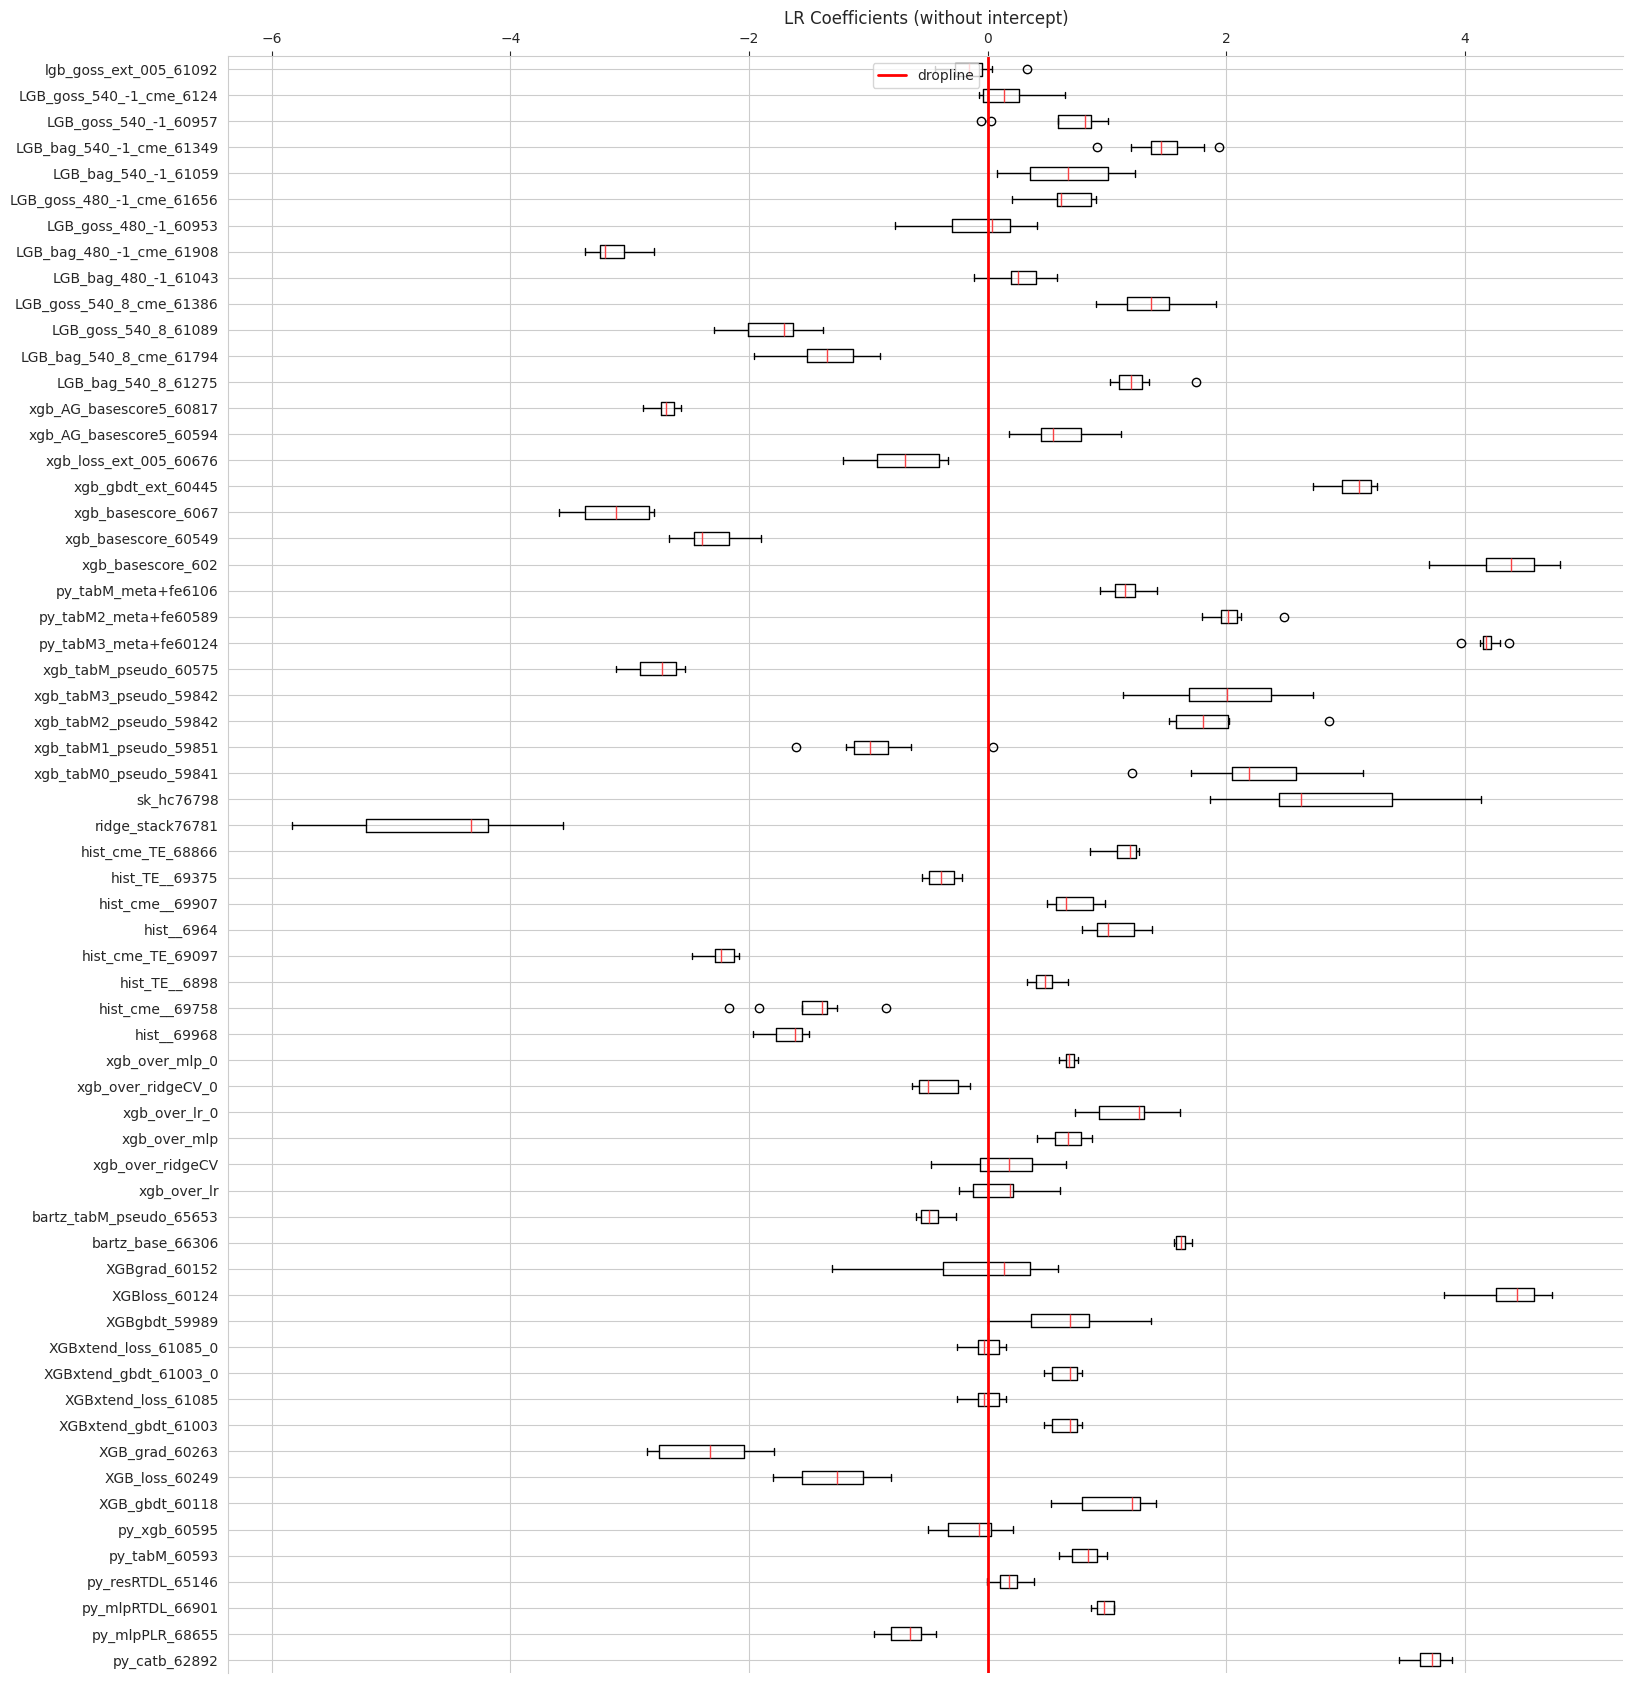

In [19]:
first_val_scores = [s for s in val_scores]

drop_cols = ['py_lgb_61185']
FEATURES = [c for c in oof_df.columns if c not in drop_cols]

model_results = inspect_models(oof_df, pred_df, TARGET, FEATURES, cv_splits=8)

So, the blended RMSE score is better without `'py_lgb_61185'`.
Let’s plot the coefficients to identify other potentially unnecessary models in this blend:

* Below, the green line represents 0.
* The boxplots show the coefficient values across folds.
* If a boxplot is on the green line, the corresponding model is probably unnecessary in this blend.

In [20]:
new_score_better = 0

for i, s in enumerate(model_results["val_scores"]):
    if s < first_val_scores[i]:
        new_score_better += 1
        
print(f"Score is better in folds {new_score_better}/{kf.n_splits} without: \n{drop_cols}")

Score is better in folds 5/8 without: 
['py_lgb_61185']


Dropping 12 model(s)... {'xgb_over_ridgeCV', 'XGBxtend_loss_61085_0', 'py_lgb_61185', 'py_xgb_60595', 'XGBxtend_loss_61085', 'LGB_goss_480_-1_60953', 'XGBgrad_60152', 'LGB_bag_480_-1_61043', 'LGB_goss_540_-1_cme_6124', 'xgb_over_lr', 'py_resRTDL_65146', 'lgb_goss_ext_005_61092'}

Fold 1/8 : 8.54109
Fold 2/8 : 8.59867
Fold 3/8 : 8.58778
Fold 4/8 : 8.55278
Fold 5/8 : 8.57868
Fold 6/8 : 8.60007
Fold 7/8 : 8.58191
Fold 8/8 : 8.58928

✅ FINAL ENSEMBLE RMSE: 8.57881


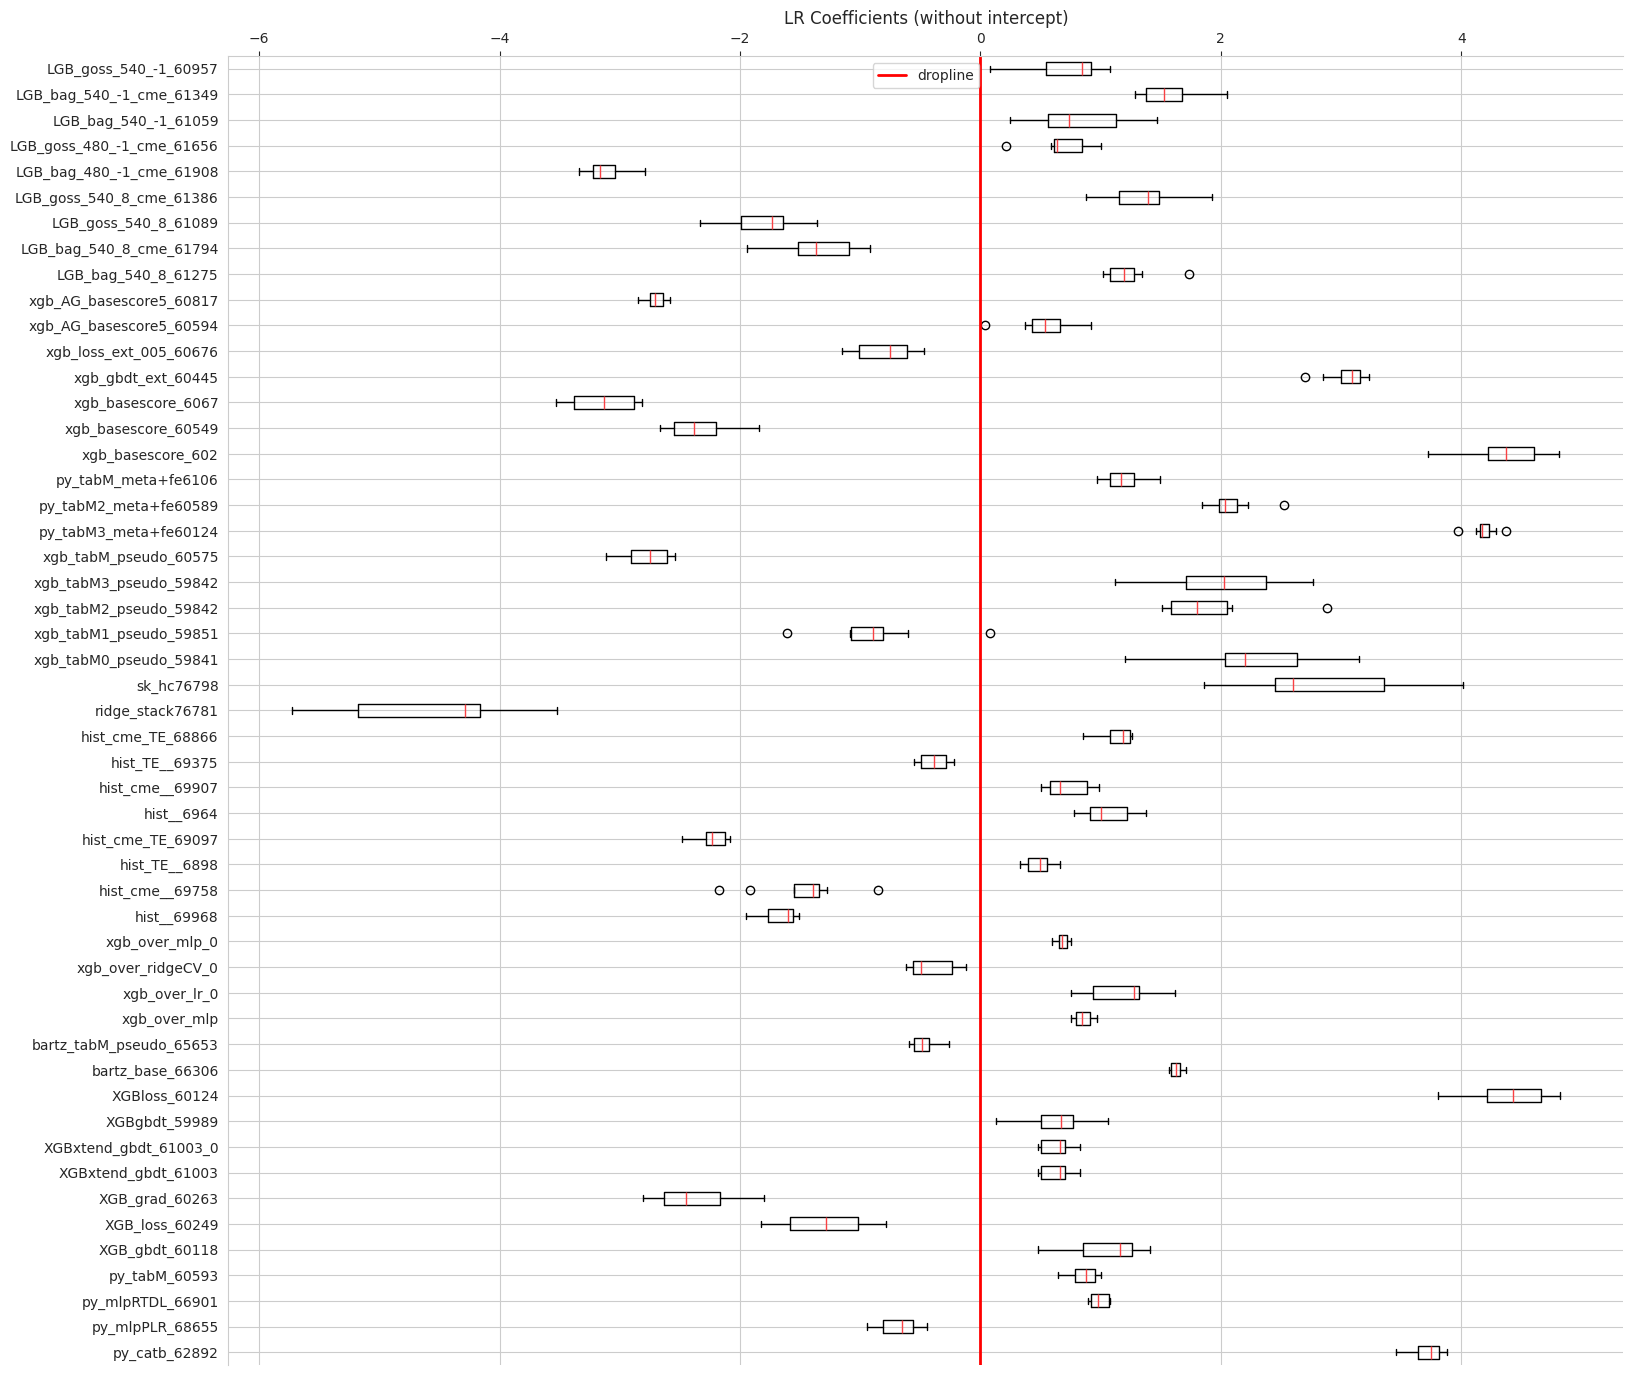

In [21]:
## -- Check plots and add features here till none show on the green line or score doesn't improve --
drop_cols.clear()

drop_cols = [
    'py_lgb_61185',
    'LGB_goss_540_-1_cme_6124',
    'LGB_goss_480_-1_60953',
    'XGBgrad_60152',
    'XGBxtend_loss_61085_0',
    'XGBxtend_loss_61085',
    'xgb_over_ridgeCV',
    'xgb_over_lr',
    'py_xgb_60595',
    'lgb_goss_ext_005_61092',
    'LGB_bag_480_-1_61043',
    'py_resRTDL_65146',
]

print(f"Dropping {len(set(drop_cols))} model(s)... {set(drop_cols)}\n")

FEATURES = [c for c in oof_df.columns if c not in set(drop_cols)]
model_results = inspect_models(oof_df, pred_df, TARGET, FEATURES, cv_splits=8)

In [22]:
new_score_better = 0

for i, s in enumerate(model_results["val_scores"]):
    if s < first_val_scores[i]:
        new_score_better += 1
        
print(f"Score is better in folds {new_score_better} / {kf.n_splits} without: \n{drop_cols}")

Score is better in folds 8 / 8 without: 
['py_lgb_61185', 'LGB_goss_540_-1_cme_6124', 'LGB_goss_480_-1_60953', 'XGBgrad_60152', 'XGBxtend_loss_61085_0', 'XGBxtend_loss_61085', 'xgb_over_ridgeCV', 'xgb_over_lr', 'py_xgb_60595', 'lgb_goss_ext_005_61092', 'LGB_bag_480_-1_61043', 'py_resRTDL_65146']


Fold 1/8: 8.54108 | Best Alpha: 14.38449888287663
Fold 2/8: 8.59866 | Best Alpha: 14.38449888287663
Fold 3/8: 8.58771 | Best Alpha: 14.38449888287663
Fold 4/8: 8.55268 | Best Alpha: 14.38449888287663
Fold 5/8: 8.57864 | Best Alpha: 14.38449888287663
Fold 6/8: 8.60003 | Best Alpha: 14.38449888287663
Fold 7/8: 8.58197 | Best Alpha: 14.38449888287663
Fold 8/8: 8.58920 | Best Alpha: 14.38449888287663

✅ FINAL ENSEMBLE RMSE: 8.57877



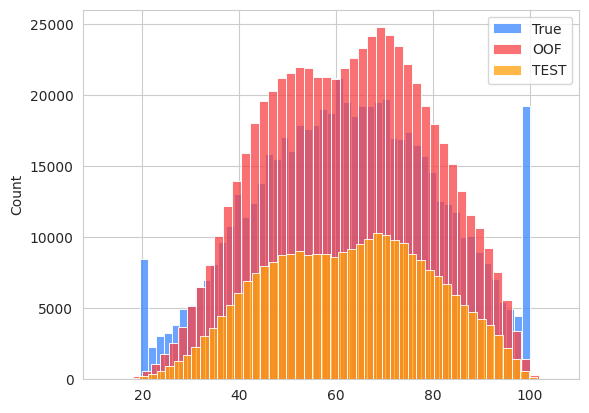


Old Ridge score: 8.57896
New Ridge score: 8.57877
CPU times: user 14min 24s, sys: 47.5 s, total: 15min 11s
Wall time: 5min 18s


In [23]:
%%time

## -- FINAL META TRAINER --
test_ridge, oof_ridge, ridge_score_new = train_ridge_meta(
    oof_df,
    pred_df,
    FEATURES,
    y,
    cv_splits=8,
    n_alphas=20,
)
print()

## -- Distribution Plots --
sns.histplot(y, label='True', bins=50)
sns.histplot(oof_ridge, label='OOF', bins=50)
sns.histplot(test_ridge, label='TEST', bins=50)
plt.legend()
plt.show()
print()

print(f"Old Ridge score: {ridge_score}")
print(f"New Ridge score: {ridge_score_new}")

In [24]:
## -- Create submission file --
n = f"{ridge_score_new}".split('.')[1]

submit[TARGET] = np.clip(test_ridge, min(y), max(y))
submit.to_csv(f"submit_stack_ridgeCV_{n}.csv", index=False)
submit.head()

,id,exam_score
0,630000,69.401283
1,630001,67.258724
2,630002,90.531884
3,630003,56.797917
4,630004,46.685645


# ENSEMBLE 2: HILL CLIMBING

In [25]:
try:
    from hillclimbers import climb_hill, partial
except:
    %pip install -qq hillclimbers
    from hillclimbers import climb_hill, partial

  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [26]:
%%time
test_hillclimb, oof_hillclimb= climb_hill(
                               train = train,
                              target = TARGET,
                         oof_pred_df = oof_df[FEATURES], # use optimum FEATURES for speed/better results
                        test_pred_df = pred_df[FEATURES], # use optimum FEATURES for speed/better results
                           objective = "minimize",
                         eval_metric = partial(root_mean_squared_error),
                    negative_weights = True,
                    return_oof_preds = True,
                           precision = 0.001,
                           plot_hill = True,
                           plot_hist = False,
    )

   /\  
  /__\  hillclimbers 
 /    \
/______\ 

Models to be ensembled | (51 total): 

xgb_tabM0_pseudo_59841:    8.59841 (best solo model)
xgb_tabM3_pseudo_59842:    8.59842
xgb_tabM2_pseudo_59842:    8.59842
xgb_tabM1_pseudo_59851:    8.59851
XGBgbdt_59989:             8.59989
XGB_gbdt_60118:            8.60118
XGBloss_60124:             8.60124
py_tabM3_meta+fe60124:     8.60124
xgb_basescore_602:         8.60200
XGB_loss_60249:            8.60249
XGB_grad_60263:            8.60263
xgb_gbdt_ext_60445:        8.60445
xgb_basescore_60549:       8.60549
xgb_tabM_pseudo_60575:     8.60575
py_tabM2_meta+fe60589:     8.60589
py_tabM_60593:             8.60593
xgb_AG_basescore5_60594:   8.60594
xgb_basescore_6067:        8.60670
xgb_loss_ext_005_60676:    8.60676
xgb_AG_basescore5_60817:   8.60817
LGB_goss_540_-1_60957:     8.60957
XGBxtend_gbdt_61003:       8.61003
XGBxtend_gbdt_61003_0:     8.61003
LGB_bag_540_-1_61059:      8.61059
py_tabM_meta+fe6106:       8.61060
LGB_goss_540_8_6108

CPU times: user 2h 35min 5s, sys: 31.7 s, total: 2h 35min 37s
Wall time: 2h 35min 44s


In [27]:
hillclimb_score = np.round(root_mean_squared_error(y, oof_hillclimb), 5)

print(f"-> Hillclimb Score: {hillclimb_score}")

print(f"""\n
-> True Avg.: {np.mean(y):.5f}
-> OOF  Avg.: {np.mean(oof_hillclimb):.5f}
-> PRED Avg.: {np.mean(test_hillclimb):.5f}
    """)
# np.save('oof_hillclimb.npy', oof_hillclimb); print(f"-> Saving hillclimb OOF...Complete!")
# np.save('test_hillclimb.npy', test_hillclimb); print(f"-> Saving hillclimb PREDS... Complete!")

## -- Create submission file --
n = f"{hillclimb_score}".split('.')[1]

submit[TARGET] = np.clip(test_hillclimb, min(y), max(y))
submit.to_csv(f"submit_hillclimb_{n}.csv", index=False)
submit.head()

-> Hillclimb Score: 8.57945


-> True Avg.: 62.50667
-> OOF  Avg.: 62.52856
-> PRED Avg.: 62.54737
    


,id,exam_score
0,630000,69.397444
1,630001,67.272150
2,630002,90.471690
3,630003,56.910552
4,630004,46.852545


# ENSEMBLE 3: OPTIMIZED BLENDING WITH SCIPY

In [28]:
from scipy.optimize import minimize
np.random.seed(SEED)

In [29]:
columns = ['ridge_'+str(ridge_score_new), 'hillclimb_'+str(hillclimb_score)]

train_final = pd.DataFrame(dict(zip(columns, [oof_ridge, oof_hillclimb])))
test_final  = pd.DataFrame(dict(zip(columns, [test_ridge, test_hillclimb])))

train_final.shape, test_final.shape

((630000, 2), (270000, 2))

In [30]:
display(train_final.head())
print()
display(test_final .head())

,ridge_8.57877,hillclimb_8.57945
0,86.669268,86.530737
1,61.218977,61.314627
2,73.827074,74.009402
3,48.671802,48.644762
4,96.636098,96.450458


,ridge_8.57877,hillclimb_8.57945
0,69.401283,69.397444
1,67.258724,67.272150
2,90.531884,90.471690
3,56.797917,56.910552
4,46.685645,46.852545


In [31]:
blend_train = []
blend_test = []

for col in train_final:
    blend_train.append(train_final[col])
blend_train = np.array(blend_train)

for col in test_final:
    blend_test.append(test_final[col])
blend_test = np.array(blend_test)

print(len(blend_train), len(blend_test))

a = 0.12345
print("{0:.2f}".format(a))

2 2
0.12


In [32]:
# BLOCK 2 - RMSE-based objective and optimization
def rmse_min_func(weights):
    # weights shape: (n_models,)
    # blend_train shape: (n_models, n_samples)
    # final_prediction should be (n_samples,)
    final_prediction = np.tensordot(weights, blend_train, axes=(0, 0))
    return root_mean_squared_error(y, final_prediction)

print("\n Finding Blending Weights (RMSE objective)...")
res_list = []
weights_list = []

n_models = blend_train.shape[0]

for k in range(10):  # Optimization rounds
    starting_values = np.random.uniform(size=n_models)
    bounds = [(0, 1)] * n_models

    res = minimize(
        rmse_min_func,
        starting_values,
        method="L-BFGS-B",
        bounds=bounds,
        options={"disp": False, "maxiter": 100000},
    )

    res_list.append(res["fun"])
    weights_list.append(res["x"])

    res_fun = format(res["fun"], '.5f')
    items = [format(item, '.5f') for item in res["x"]]

    print(
        "{iter}\tScore: {score}\tWeights: {weights}".format(
            iter=(k + 1),
            score=res_fun,
            weights="\t".join([str(item) for item in items]),
        )
    )

bestRMSE = min(res_list)  # lower is better
bestWght = weights_list[int(np.argmin(res_list))]
weights = bestWght

blend_score = round(bestRMSE, 5)


 Finding Blending Weights (RMSE objective)...
1	Score: 8.57894	Weights: 0.28262	0.71739
2	Score: 8.57869	Weights: 0.55010	0.44990
3	Score: 8.57865	Weights: 0.71825	0.28175
4	Score: 8.57865	Weights: 0.71832	0.28168
5	Score: 8.57875	Weights: 0.45915	0.54085
6	Score: 8.57938	Weights: 0.02983	0.97019
7	Score: 8.57866	Weights: 0.79670	0.20329
8	Score: 8.57865	Weights: 0.71820	0.28179
9	Score: 8.57880	Weights: 0.40585	0.59416
10	Score: 8.57869	Weights: 0.55510	0.44490


Ensemble RMSE: 8.57865

 ----------------
 Weights | Model:
 ----------------
 0.71820 * model-1
 0.28179 * model-2



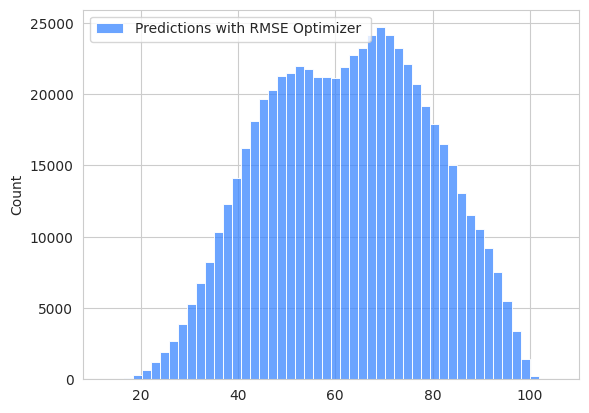

In [33]:
# BLOCK 3 - reporting and final model
print('Ensemble RMSE: {best_score}'.format(best_score=blend_score))
# print('\n Best Weights: {weights}'.format(weights=bestWght))

train_prices = np.zeros(len(blend_train[0]))
test_prices  = np.zeros(len(blend_test[0]))

print('\n ----------------')
print(' Weights | Model:')
print(' ----------------')
for k in range(len(blend_test)):
    print(' %.5f * model-%d' % (weights[k], (k + 1)))
    test_prices += blend_test[k] * weights[k]

for k in range(len(blend_train)):
    train_prices += blend_train[k] * weights[k]

# Optional: normalize weights to sum to 1 (same as before)
bestWght /= np.sum(bestWght)
print()
# BLOCK 4 - optional visualization (unchanged logic)
optimized_oof = np.tensordot(bestWght, train_final, axes=((0), (1)))  # shape (n_samples,)
sns.histplot(optimized_oof, bins=50, label=f'Predictions with RMSE Optimizer ')
plt.legend()
plt.show()

In [34]:
## -- APPLY WEIGHTS TO TEST PREDICTIONS --
optimized_test = test_final.values.dot(weights)
submit[TARGET] = np.clip(optimized_test, min(y), max(y))
submit.to_csv(f"submit_Optimized_Blend_{str(blend_score).split('.')[1]}.csv", index=False)
submit.head()

,id,exam_score
0,630000,69.400201
1,630001,67.262507
2,630002,90.514922
3,630003,56.829657
4,630004,46.732676
